In [ ]:
!pip install pycocotools opencv-python


In [1]:
!gdown https://drive.google.com/uc?id=1XnKFKqjoa95PLXFw01HcXx4Az49Qw37i


Downloading...
From (original): https://drive.google.com/uc?id=1XnKFKqjoa95PLXFw01HcXx4Az49Qw37i
From (redirected): https://drive.google.com/uc?id=1XnKFKqjoa95PLXFw01HcXx4Az49Qw37i&confirm=t&uuid=f0d38db8-97c8-4132-916d-0005906889d3
To: /content/UBC_v1.0.zip
100% 707M/707M [00:08<00:00, 86.9MB/s]


In [2]:
!unzip /content/UBC_v1.0.zip

Archive:  /content/UBC_v1.0.zip
   creating: annotations/
  inflating: annotations/roof_coarse_train.json  
  inflating: annotations/roof_coarse_val.json  
  inflating: annotations/roof_fine_train.json  
  inflating: annotations/roof_fine_val.json  
  inflating: annotations/use_coarse_train.json  
  inflating: annotations/use_coarse_val.json  
   creating: train/
  inflating: train/Beijing_GF2_L1A0004822322-MSS1_12600_12600_116.3162_39.9349.xml  
  inflating: train/Beijing_GF2_L1A0004822322-MSS1_12600_12600_116.3162_39.9349_RGB.tif  
  inflating: train/Beijing_GF2_L1A0004822322-MSS1_12600_13000_116.3163_39.9320.xml  
  inflating: train/Beijing_GF2_L1A0004822322-MSS1_12600_13000_116.3163_39.9320_RGB.tif  
  inflating: train/Beijing_GF2_L1A0004822322-MSS1_13000_12600_116.3200_39.9349.xml  
  inflating: train/Beijing_GF2_L1A0004822322-MSS1_13000_12600_116.3200_39.9349_RGB.tif  
  inflating: train/Beijing_GF2_L1A0004822322-MSS1_13000_13000_116.3200_39.9321.xml  
  inflating: train/Beijing_

In [9]:
import json

with open("/content/annotations/use_coarse_train.json") as f:
  data = json.load(f)

In [8]:
data.keys()

dict_keys(['images', 'annotations', 'categories'])

In [10]:
data["categories"]

[{'supercategory': 'residential', 'id': 1, 'name': 'residential'},
 {'supercategory': 'commercial', 'id': 2, 'name': 'commercial'},
 {'supercategory': 'industrial', 'id': 3, 'name': 'industrial'},
 {'supercategory': 'public', 'id': 4, 'name': 'public'},
 {'supercategory': 'other', 'id': 5, 'name': 'other'}]

In [ ]:
from pycocotools.coco import COCO
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np

In [ ]:
coco = COCO('/content/annotations/use_coarse_train.json')

loading annotations into memory...
Done (t=0.31s)
creating index...
index created!


In [ ]:
def generate_mask(coco, output_dir, img_ids=None):
    count = 0
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # If no specific image IDs are provided, process all
    if img_ids is None:
        img_ids = coco.getImgIds()

    cat_ids = coco.getCatIds()
    imgs = coco.loadImgs(img_ids)

    for img in imgs:
        anns_ids = coco.getAnnIds(imgIds=img['id'], catIds=cat_ids, iscrowd=None)
        anns = coco.loadAnns(anns_ids)
        anns_img = np.zeros((img['height'], img['width']), dtype=np.uint8)

        for ann in anns:
            mask = coco.annToMask(ann)
            anns_img = np.maximum(anns_img, mask * ann['category_id'])

        # Save mask as PNG
        filename = os.path.splitext(img['file_name'])[0]  + "_mask.png"
        save_path = os.path.join(output_dir, filename)
        cv2.imwrite(save_path, anns_img)




In [ ]:
generate_mask(coco, '/content/trainMask')

loading annotations into memory...
Done (t=0.60s)
creating index...
index created!


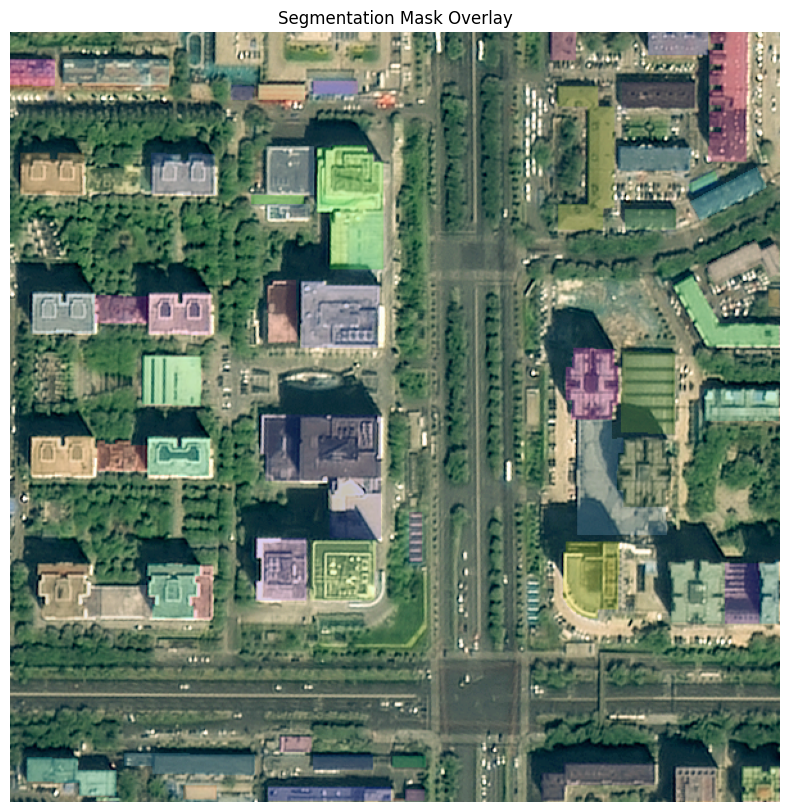

In [ ]:
from pycocotools.coco import COCO
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Paths
annotation_path = '/content/annotations/use_coarse_train.json'
image_folder = '/content/train/' # Added a trailing slash

# Load COCO
coco = COCO(annotation_path)

# Load image info
img_ids = coco.getImgIds()
img = coco.loadImgs(img_ids[0])[0]  # Change index as needed
image_path = image_folder + img['file_name']
original_img = cv2.imread(image_path)

# Check if image loaded successfully
if original_img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # Get annotations
    cat_ids = coco.getCatIds()
    ann_ids = coco.getAnnIds(imgIds=img['id'], catIds=cat_ids, iscrowd=None)
    anns = coco.loadAnns(ann_ids)

    # Generate overlay mask with transparency
    overlay = original_img.copy()
    for ann in anns:
        mask = coco.annToMask(ann)
        color = np.random.randint(0, 255, (3,), dtype=np.uint8)  # Random color per object
        for c in range(3):
            overlay[:, :, c] = np.where(mask == 1,
                                        overlay[:, :, c] * 0.5 + color[c] * 0.5,
                                        overlay[:, :, c])

    # Blend original and overlay
    blended = cv2.addWeighted(original_img, 0.5, overlay, 0.5, 0)

    # Show image
    plt.figure(figsize=(10, 10))
    plt.imshow(blended)
    plt.title("Segmentation Mask Overlay")
    plt.axis("off")
    plt.show()

In [ ]:
def resize_images_and_masks(
    input_image_folder,
    input_mask_folder,
    output_image_folder,
    output_mask_folder,
    target_size=(512, 512)
):
    os.makedirs(output_image_folder, exist_ok=True)
    os.makedirs(output_mask_folder, exist_ok=True)

    for file_name in os.listdir(input_image_folder):
        if not file_name.lower().endswith(".tif"):
            continue

        # Build paths
        image_path = os.path.join(input_image_folder, file_name)
        base_name = os.path.splitext(file_name)[0]
        mask_path = os.path.join(input_mask_folder, base_name + "_mask.png")

        if not os.path.exists(mask_path):
            print(f"[SKIP] Mask not found for {file_name}")
            continue

        # Load image and mask
        image = np.array(Image.open(image_path).convert("RGB"))
        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

        # Resize
        image_resized = cv2.resize(image, target_size, interpolation=cv2.INTER_LINEAR)
        mask_resized = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)

        # Save outputs
        out_img_path = os.path.join(output_image_folder, base_name + ".jpg")
        out_mask_path = os.path.join(output_mask_folder, base_name + "_mask.png")

        cv2.imwrite(out_img_path, cv2.cvtColor(image_resized, cv2.COLOR_RGB2BGR))
        cv2.imwrite(out_mask_path, mask_resized)

        print(f"[DONE] Resized: {file_name} and mask.")

# Example usage
resize_images_and_masks(
    input_image_folder='/content/train',
    input_mask_folder='/content/trainMask',
    output_image_folder='resized/images/',
    output_mask_folder='resized_masks/masks/',
    target_size=(512, 512)
)


[DONE] Resized: Munich_SV1-03_L2A0001092311_3600_9000_11.5472_48.1464_RGB.tif and mask.
[DONE] Resized: Munich_GF2_L1A0000926980-MSS2_18000_22000_11.5051_48.1302_RGB.tif and mask.
[DONE] Resized: Beijing_SV1-02_L2A0001092309_6300_1300_116.3113_39.9730_RGB.tif and mask.
[DONE] Resized: Beijing_SV1-02_L2A0001092309_13900_7200_116.3561_39.9467_RGB.tif and mask.
[DONE] Resized: Munich_SV1-03_L2A0001092311_9000_5400_11.5842_48.1618_RGB.tif and mask.
[DONE] Resized: Munich_SV1-03_L2A0001092311_7600_12100_11.5733_48.1319_RGB.tif and mask.
[DONE] Resized: Beijing_SV1-02_L2A0001092309_12100_9400_116.3456_39.9367_RGB.tif and mask.
[DONE] Resized: Beijing_GF2_L1A0004822322-MSS1_15300_19300_116.3420_39.8868_RGB.tif and mask.
[DONE] Resized: Beijing_GF2_L1A0004822322-MSS1_24700_19300_116.4299_39.8872_RGB.tif and mask.
[DONE] Resized: Munich_SV1-03_L2A0001092311_3100_4500_11.5448_48.1667_RGB.tif and mask.
[DONE] Resized: Munich_SV1-03_L2A0001092311_3100_14400_11.5426_48.1222_RGB.tif and mask.
[DONE]

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Paths
image_path = '/content/image.jpg'       # Your resized image
mask_path = '/content/resized_masks/masks/Beijing_GF2_L1A0004822322-MSS1_13000_13000_116.3200_39.9321_RGB_mask.png'    # Your resized mask

# Load image and mask
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(image_np, cv2.IMREAD_UNCHANGED)  # Single channel

# Define number of classes (excluding background 0)
num_classes = int(mask.max())

# Create a color map for the classes
colors = np.random.randint(0, 255, size=(num_classes + 1, 3), dtype=np.uint8)
colors[0] = [0, 0, 0]  # background stays black / transparent

# Convert mask to RGB using the color map
colored_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
for class_id in range(1, num_classes + 1):
    colored_mask[mask == class_id] = colors[class_id]

# Blend the mask with the image
alpha = 0.5
overlay = cv2.addWeighted(image, 1 - alpha, colored_mask, alpha, 0)

# Show result
plt.figure(figsize=(8, 8))
plt.imshow(overlay)
plt.title("Colored Segmentation Mask Overlay")
plt.axis("off")
plt.show()


error: OpenCV(4.11.0) :-1: error: (-5:Bad argument) in function 'imread'
> Overload resolution failed:
>  - Expected 'filename' to be a str or path-like object
>  - Expected 'filename' to be a str or path-like object
>  - Expected 'filename' to be a str or path-like object


In [ ]:
#import gdrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r /content/resized_masks /content/drive/MyDrive/

In [ ]:
coco_val = COCO('/content/annotations/use_coarse_val.json')

loading annotations into memory...
Done (t=0.06s)
creating index...
index created!


In [ ]:
generate_mask(coco_val, '/content/valMask')

In [ ]:
resize_images_and_masks(
    input_image_folder='/content/val',
    input_mask_folder='/content/valMask',
    output_image_folder='resized_val/images/',
    output_mask_folder='resized_masks_val/masks/',
    target_size=(512, 512)
)


[DONE] Resized: Munich_SV1-03_L2A0001092311_14400_6300_11.6203_48.1569_RGB.tif and mask.
[DONE] Resized: Beijing_SV1-02_L2A0001092309_4000_10300_116.2983_39.9324_RGB.tif and mask.
[DONE] Resized: Munich_SV1-03_L2A0001092311_7200_5800_11.5721_48.1603_RGB.tif and mask.
[DONE] Resized: Munich_SV1-03_L2A0001092311_4000_900_11.5517_48.1828_RGB.tif and mask.
[DONE] Resized: Munich_SV1-03_L2A0001092311_4900_12100_11.5552_48.1323_RGB.tif and mask.
[DONE] Resized: Beijing_SV1-02_L2A0001092309_3600_10300_116.2959_39.9324_RGB.tif and mask.
[DONE] Resized: Munich_SV1-03_L2A0001092311_10800_16600_11.5938_48.1112_RGB.tif and mask.
[DONE] Resized: Beijing_GF2_L1A0004822322-MSS1_11700_17500_116.3082_39.8995_RGB.tif and mask.
[DONE] Resized: Munich_SV1-03_L2A0001092311_6300_10800_11.5649_48.1380_RGB.tif and mask.
[DONE] Resized: Munich_SV1-03_L2A0001092311_6300_14400_11.5641_48.1218_RGB.tif and mask.
[DONE] Resized: Beijing_SV1-02_L2A0001092307_7600_4500_116.3848_39.9942_RGB.tif and mask.
[DONE] Resize

In [11]:
!pip install -q transformers datasets evaluate segments-ai
!apt-get install git-lfs
!git lfs install
# huggingface-cli login


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 5.0 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
Git LFS initialized.


In [12]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) y
Token is valid (permission: write).
The token `building` has been saved to /root/.cache/huggingface/stored_tokens
Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when 

In [ ]:
from datasets import Dataset, DatasetDict, Image
from pathlib import Path

def create_split(image_dir, mask_dir):
    image_dir = Path(image_dir)
    mask_dir = Path(mask_dir)

    image_files = sorted([str(f) for f in image_dir.iterdir() if f.suffix == ".png"])
    mask_files = sorted([str(f) for f in mask_dir.iterdir() if f.suffix == ".png"])

    data = [{"image": img, "mask": msk} for img, msk in zip(image_files, mask_files)]

    ds = Dataset.from_list(data)
    ds = ds.cast_column("image", Image())
    ds = ds.cast_column("mask", Image())
    return ds


# Build splits
train_dataset = create_split("/content/resized/images", "/content/resized_masks/masks")
val_dataset = create_split("/content/resized_val/images", "/content/resized_masks_val/masks")

# Combine into DatasetDict
dataset = DatasetDict({
    "train": train_dataset,
    "val": val_dataset
})

dataset

# Push to Hugging Face



DatasetDict({
    train: Dataset({
        features: ['image', 'mask'],
        num_rows: 0
    })
    val: Dataset({
        features: ['image', 'mask'],
        num_rows: 0
    })
})

In [ ]:
from datasets import Dataset, DatasetDict, Image
from pathlib import Path
import os

def create_split(image_dir, mask_dir):
    """Create dataset split with proper validation"""
    image_dir = Path(image_dir)
    mask_dir = Path(mask_dir)

    # Check if directories exist
    if not image_dir.exists():
        raise FileNotFoundError(f"Image directory not found: {image_dir}")
    if not mask_dir.exists():
        raise FileNotFoundError(f"Mask directory not found: {mask_dir}")

    # Get all PNG files
    image_files = sorted([f for f in image_dir.iterdir() if f.suffix.lower() == ".jpg"])
    mask_files = sorted([f for f in mask_dir.iterdir() if f.suffix.lower() == ".png"])

    print(f"Found {len(image_files)} images in {image_dir}")
    print(f"Found {len(mask_files)} masks in {mask_dir}")

    # Check if counts match
    if len(image_files) != len(mask_files):
        print(f"WARNING: Mismatch - {len(image_files)} images vs {len(mask_files)} masks")

        # Try to match by filename
        image_stems = {f.stem: str(f) for f in image_files}
        mask_stems = {f.stem: str(f) for f in mask_files}

        matched_pairs = []
        for stem in image_stems:
            if stem in mask_stems:
                matched_pairs.append({"pixel_values": image_stems[stem], "label": mask_stems[stem]})

        print(f"Matched {len(matched_pairs)} pairs by filename")
        data = matched_pairs
    else:
        # Assume files are properly sorted and match by position
        data = [{"pixel_values": str(img), "label": str(msk)} for img, msk in zip(image_files, mask_files)]

    if not data:
        raise ValueError("No matching image-mask pairs found!")

    # Create dataset
    ds = Dataset.from_list(data)
    ds = ds.cast_column("pixel_values", Image())
    ds = ds.cast_column("label", Image())

    print(f"Created dataset with {len(ds)} samples")
    return ds

def validate_paths():
    """Validate all required paths exist"""
    paths = {
        "train_images": "/content/resized/images",
        "train_masks": "/content/resized_masks/masks",
        "val_images": "/content/resized_val/images",
        "val_masks": "/content/resized_masks_val/masks"
    }

    for name, path in paths.items():
        if not os.path.exists(path):
            print(f"❌ {name}: {path} - NOT FOUND")
            return False
        else:
            count = len([f for f in os.listdir(path) if f.lower().endswith('.png')])
            print(f"✅ {name}: {path} - {count} PNG files")

    return True

# Validate paths first
print("=== Validating Paths ===")
if not validate_paths():
    print("Fix the missing directories before proceeding!")
    exit()

print("\n=== Creating Datasets ===")

try:
    # Build splits
    train_dataset = create_split("/content/resized/images", "/content/resized_masks/masks")
    val_dataset = create_split("/content/resized_val/images", "/content/resized_masks_val/masks")

    # Combine into DatasetDict
    dataset = DatasetDict({
        "train": train_dataset,
        "val": val_dataset
    })

    print(f"\n=== Dataset Summary ===")
    print(f"Train samples: {len(dataset['train'])}")
    print(f"Val samples: {len(dataset['val'])}")
    print(f"Total samples: {len(dataset['train']) + len(dataset['val'])}")

    # Show sample
    print(f"\n=== Sample Data ===")
    sample = dataset['train'][0]
    print(f"Image shape: {sample['pixel_values'].size}")
    print(f"Mask shape: {sample['label'].size}")

    print("\n✅ Dataset created successfully!")

except Exception as e:
    print(f"❌ Error creating dataset: {e}")
    print("Check your file paths and ensure images and masks are properly paired")


# Uncomment to push to hub
# push_to_hub(dataset, "your-username/your-dataset-name", private=True)

=== Validating Paths ===
✅ train_images: /content/resized/images - 0 PNG files
✅ train_masks: /content/resized_masks/masks - 560 PNG files
✅ val_images: /content/resized_val/images - 0 PNG files
✅ val_masks: /content/resized_masks_val/masks - 160 PNG files

=== Creating Datasets ===
Found 560 images in /content/resized/images
Found 560 masks in /content/resized_masks/masks
Created dataset with 560 samples
Found 160 images in /content/resized_val/images
Found 160 masks in /content/resized_masks_val/masks
Created dataset with 160 samples

=== Dataset Summary ===
Train samples: 560
Val samples: 160
Total samples: 720

=== Sample Data ===
Image shape: (512, 512)
Mask shape: (512, 512)

✅ Dataset created successfully!


In [ ]:
dataset.push_to_hub("tferhan/urban_building_dataset_mask_512")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/560 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/6 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

README.md:   0%|          | 0.00/412 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/tferhan/urban_building_dataset_mask_512/commit/a1a9fa76920d28cab6a37b39f7c15fbdaf5cf39d', commit_message='Upload dataset', commit_description='', oid='a1a9fa76920d28cab6a37b39f7c15fbdaf5cf39d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/tferhan/urban_building_dataset_mask_512', endpoint='https://huggingface.co', repo_type='dataset', repo_id='tferhan/urban_building_dataset_mask_512'), pr_revision=None, pr_num=None)

In [2]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 12.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [17]:
from datasets import load_dataset
ds = load_dataset("tferhan/urban_building_dataset_mask_512", download_mode="force_redownload")

train-00000-of-00001.parquet:   0%|          | 0.00/87.7M [00:00<?, ?B/s]

val-00000-of-00001.parquet:   0%|          | 0.00/24.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/560 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/160 [00:00<?, ? examples/s]

In [3]:
from datasets import DatasetDict
import numpy as np
# Your class mapping
def remap_mask(example):
    mask = np.array(example["label"])

    mask[(mask == 3) | (mask == 4) | (mask == 5)] = 2
    return {"label": mask}

# Apply to the DatasetDict

dataset["train"] = ds["train"].map(remap_mask, num_proc=8)
dataset["val"] = ds["val"].map(remap_mask, num_proc=8)


Map (num_proc=8):   0%|          | 0/560 [00:00<?, ? examples/s]

TimeoutError: 

In [10]:
from datasets import Dataset

import numpy as np

def remap_all_masks(split_dataset):
    new_labels = []
    for example in split_dataset:
        mask = np.array(example["label"])
        mask[(mask == 3) | (mask == 4) | (mask == 5)] = 2
        new_labels.append(mask)
    # Create a new dataset with the same features except labels replaced
    features = split_dataset.features.copy()
    # If needed, adjust 'label' feature type here (e.g. from Image to Array2D)
    new_ds = Dataset.from_dict({
        "pixel_values": [ex["pixel_values"] for ex in split_dataset],
        "label": new_labels,
    })
    return new_ds

ds["train"] = remap_all_masks(ds["train"])
ds["val"] = remap_all_masks(ds["val"])


In [12]:
def check_classes(dataset_split):
    unique_classes = set()
    for example in dataset_split:
        mask = np.array(example["label"])
        unique_classes.update(np.unique(mask).tolist())
    return sorted(unique_classes)

print("Train classes:", check_classes(ds["train"]))
print("Val classes:", check_classes(ds["val"]))


Train classes: [0, 1, 2]
Val classes: [0, 1, 2]


In [16]:
ds["train"][0]

{'pixel_values': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x512>,
 'label': [[0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   

In [ ]:
pretrain_data["train"][0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=683x512>,
 'annotation': <PIL.PngImagePlugin.PngImageFile image mode=L size=683x512>,
 'scene_category': 768}

In [2]:
train_ds = ds["train"]
test_ds = ds["val"]


In [ ]:
import json

In [ ]:
coco = COCO("/content/annotations/use_coarse_train.json")

loading annotations into memory...
Done (t=0.51s)
creating index...
index created!


In [ ]:
with open("/content/annotations/use_coarse_train.json") as f:
  data = json.load(f)

In [16]:
import numpy as np
import torch
from collections import Counter
from datasets import DatasetDict

def compute_class_distribution_hf(dataset_split, num_classes):
    pixel_counts = np.zeros(num_classes, dtype=np.int64)

    for example in dataset_split:
        mask = example["label"]  # Assuming mask is a numpy array or list
        mask = np.array(mask)
        for class_id in range(num_classes):
            pixel_counts[class_id] += np.sum(mask == class_id)

    total_pixels = pixel_counts.sum()
    class_distribution = pixel_counts / total_pixels

    return pixel_counts, class_distribution
n_classes = 6  # example: 0=background, 1=commercial, 2=residential, 3=others

train_split = ds["train"]
pixel_counts, class_distribution = compute_class_distribution_hf(train_split, n_classes)

print("Pixel counts per class:", pixel_counts)
print("Normalized distribution:", class_distribution)

Pixel counts per class: [107911923  19946070   8362251   1501943   6996584   2081869]
Normalized distribution: [0.73509164 0.13587182 0.05696331 0.01023117 0.04766045 0.01418161]


In [17]:
import numpy as np
import torch

dist = np.array([0.73509164, 0.13587182, 0.05696331, 0.01023117, 0.04766045, 0.01418161])
inv = 1.0 / (dist + 1e-6)
weights = inv / inv.sum() * len(inv)  # normalize to sum ≈ num_classes

# Final weight tensor:
weights = torch.tensor(weights, dtype=torch.float32)
print(weights)


tensor([0.0379, 0.2049, 0.4888, 2.7211, 0.5842, 1.9632])


In [ ]:
data.keys()

dict_keys(['images', 'annotations', 'categories'])

In [ ]:
data["categories"]

[{'supercategory': 'residential', 'id': 1, 'name': 'residential'},
 {'supercategory': 'commercial', 'id': 2, 'name': 'commercial'},
 {'supercategory': 'industrial', 'id': 3, 'name': 'industrial'},
 {'supercategory': 'public', 'id': 4, 'name': 'public'},
 {'supercategory': 'other', 'id': 5, 'name': 'other'}]

In [ ]:
to_keep = ["palm", ]

In [3]:
labels = {"0": "background", "1" : "residential", "2":"commercial", "3":"industrial", "4":"public", "5":"other"}

In [4]:
id2label = {int(k): v for k, v in labels.items()}
label2id = {v: k for k, v in id2label.items()}

In [5]:
num_labels = len(id2label)

In [6]:
num_labels

6

In [7]:
from torchvision.transforms import ColorJitter
from transformers import SegformerImageProcessor

processor = SegformerImageProcessor()
jitter = ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.1)

In [9]:
def train_transforms(example_batch):
    images = [jitter(x) for x in example_batch['pixel_values']]
    labels = [x for x in example_batch['label']]
    inputs = processor(images, labels)
    return inputs


def val_transforms(example_batch):
    images = [x for x in example_batch['pixel_values']]
    labels = [x for x in example_batch['label']]
    inputs = processor(images, labels)
    return inputs

In [8]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
from transformers import SegformerImageProcessor

processor = SegformerImageProcessor()

# Fixed augmentation pipeline
train_augment = A.Compose([
    # Geometric augmentations
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(-0.1, 0.1), rotate=(-15, 15), p=0.5),  # Fixed
    A.ElasticTransform(p=0.3),

    # Photometric augmentations (satellite-specific)
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.8),
    A.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.1, p=0.7),
    A.RandomGamma(gamma_limit=(80, 120), p=0.5),
    A.Blur(blur_limit=3, p=0.3),
    A.CLAHE(p=0.3),
])

def train_transforms(example_batch):
    images = []
    labels = []

    for img, label in zip(example_batch['pixel_values'], example_batch['label']):
        # Convert to numpy if tensor
        if hasattr(img, 'numpy'):
            img_np = img.numpy()
        else:
            img_np = np.array(img)

        if hasattr(label, 'numpy'):
            label_np = label.numpy()
        else:
            label_np = np.array(label)

        # Apply augmentations
        augmented = train_augment(image=img_np, mask=label_np)

        images.append(augmented['image'])
        labels.append(augmented['mask'])

    inputs = processor(images, labels)
    return inputs

def val_transforms(example_batch):
    images = [x for x in example_batch['pixel_values']]
    labels = [x for x in example_batch['label']]
    inputs = processor(images, labels)
    return inputs

In [9]:
train_ds.set_transform(train_transforms)
test_ds.set_transform(val_transforms)

In [10]:
from transformers import SegformerForSemanticSegmentation

pretrained_model_name = "tferhan/segformer-b1-finetuned-UBC"
model = SegformerForSemanticSegmentation.from_pretrained(
    pretrained_model_name,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)


In [11]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    "segformer-b4-finetuned-UBC-focal",
    learning_rate=6e-5,
    num_train_epochs=30,
    per_device_train_batch_size=4,  # bump if possible
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,  # if batch_size still too small
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="eval_mean_iou",
    fp16=True
)

In [27]:
!pip install evaluate

In [12]:
import torch
from torch import nn
import evaluate

metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
  with torch.no_grad():
    logits, labels = eval_pred
    logits_tensor = torch.from_numpy(logits)
    logits_tensor = nn.functional.interpolate(
        logits_tensor,
        size=labels.shape[-2:],
        mode="bilinear",
        align_corners=False,
    ).argmax(dim=1)

    pred_labels = logits_tensor.detach().cpu().numpy()
    metrics = metric.compute(
        predictions=pred_labels,
        references=labels,
        num_labels=len(id2label),
        ignore_index=0,
        reduce_labels=processor.do_reduce_labels,
    )

    per_category_accuracy = metrics.pop("per_category_accuracy").tolist()
    per_category_iou = metrics.pop("per_category_iou").tolist()

    metrics.update({f"accuracy_{id2label[i]}": v for i, v in enumerate(per_category_accuracy)})
    metrics.update({f"iou_{id2label[i]}": v for i, v in enumerate(per_category_iou)})

    return metrics


In [32]:
!pip install segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [14]:
!pip install focal-loss-torch

In [13]:
from focal_loss.focal_loss import FocalLoss
import segmentation_models_pytorch as smp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
class_weights = torch.tensor([0.0379, 0.2049, 0.4888, 2.7211, 0.5842, 1.9632], device=device)

focal_loss = smp.losses.FocalLoss(mode='multiclass', gamma=2.0, )
dice_loss = smp.losses.DiceLoss('multiclass')
def custom_loss_function_focal_dice(outputs, labels, num_items_in_batch=None):
    logits = outputs.get("logits")

    if logits.shape[-2:] != labels.shape[-2:]:
        logits = nn.functional.interpolate(
            logits,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
    focal = focal_loss(logits, labels)
    ce_loss = nn.functional.cross_entropy(logits, labels, weight=class_weights)
    dice = dice_loss(logits, labels)


    return ce_loss + 0.8 * dice


cuda


In [14]:
import torch.nn as nn
from transformers import Trainer

def custom_loss_function(outputs, labels, num_items_in_batch=None):
    logits = outputs.get("logits")

    # Upsample logits to match label size if needed
    if logits.shape[-2:] != labels.shape[-2:]:
        logits = nn.functional.interpolate(
            logits,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

    # Flatten for loss computation
    logits_flat = logits.permute(0, 2, 3, 1).reshape(-1, logits.shape[1])
    labels_flat = labels.reshape(-1)

    # Cross entropy loss ignoring index 0 (background)
    loss_fct = nn.CrossEntropyLoss(ignore_index=0)
    loss = loss_fct(logits_flat, labels_flat)

    return loss

In [16]:
!pip install wandb

In [15]:
from transformers import Trainer
from transformers import TrainerCallback
import os


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
    compute_loss_func=custom_loss_function_focal_dice
)


In [ ]:
import os
os.environ["WANDB_DISABLE"] = "true"
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


In [20]:
import torch
print(torch.cuda.is_available())          # Should be True
print(torch.cuda.device_count())          # Should be >= 1
print(torch.cuda.get_device_name(0))      # Your GPU name


True
1
Tesla T4


In [ ]:
import torch

unique_values = set()

for example in train_ds.select(range(20)):  # sample 20 examples
    labels = example["labels"]
    if isinstance(labels, torch.Tensor):
        labels = labels.numpy()
    unique_values.update(set(labels.flatten().tolist()))

print("Unique label values in training set:", sorted(unique_values))


[<PIL.PngImagePlugin.PngImageFile image mode=L size=512x512 at 0x7FD50EAF9110>]
[<PIL.PngImagePlugin.PngImageFile image mode=L size=512x512 at 0x7FD50EB11510>]
[<PIL.PngImagePlugin.PngImageFile image mode=L size=512x512 at 0x7FD50EB13410>]
[<PIL.PngImagePlugin.PngImageFile image mode=L size=512x512 at 0x7FD52D20D910>]
[<PIL.PngImagePlugin.PngImageFile image mode=L size=512x512 at 0x7FD5211B8290>]
[<PIL.PngImagePlugin.PngImageFile image mode=L size=512x512 at 0x7FD50EAF8E50>]
[<PIL.PngImagePlugin.PngImageFile image mode=L size=512x512 at 0x7FD50EAFB0D0>]
[<PIL.PngImagePlugin.PngImageFile image mode=L size=512x512 at 0x7FD50EAF8E50>]
[<PIL.PngImagePlugin.PngImageFile image mode=L size=512x512 at 0x7FD585C51510>]
[<PIL.PngImagePlugin.PngImageFile image mode=L size=512x512 at 0x7FD50EB12250>]
[<PIL.PngImagePlugin.PngImageFile image mode=L size=512x512 at 0x7FD585C50990>]
[<PIL.PngImagePlugin.PngImageFile image mode=L size=512x512 at 0x7FD50EB36F10>]
[<PIL.PngImagePlugin.PngImageFile image 

In [16]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Currently logged in as: tferhan (tferhan-ng) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Mean Iou,Mean Accuracy,Overall Accuracy,Accuracy Background,Accuracy Residential,Accuracy Commercial,Accuracy Industrial,Accuracy Public,Accuracy Other,Iou Background,Iou Residential,Iou Commercial,Iou Industrial,Iou Public,Iou Other
1,3.056500,1.645644,0.299975,0.522724,0.626937,nan,0.802324,0.498310,0.689659,0.522065,0.101260,0.000000,0.716777,0.375611,0.249239,0.367737,0.090488
2,2.672200,1.577009,0.315979,0.519000,0.645747,nan,0.836120,0.519654,0.467078,0.467566,0.304580,0.000000,0.726900,0.397657,0.212376,0.355225,0.203718
3,2.664100,1.607249,0.298354,0.566296,0.614800,nan,0.790819,0.494003,0.830943,0.369754,0.345958,0.000000,0.725211,0.348547,0.228917,0.280139,0.207311
4,2.388300,1.635622,0.307107,0.544825,0.627969,nan,0.798920,0.512722,0.629757,0.429452,0.353275,0.000000,0.721773,0.372406,0.251046,0.299149,0.198270
5,2.480600,1.596299,0.289478,0.589167,0.597803,nan,0.793199,0.314800,0.873151,0.419880,0.544804,0.000000,0.716398,0.270118,0.216375,0.311836,0.222138
6,2.236000,1.615802,0.302296,0.568139,0.608750,nan,0.739875,0.507484,0.751249,0.451380,0.390707,0.000000,0.698511,0.355851,0.251802,0.301918,0.205691
7,1.956600,1.637538,0.303241,0.561056,0.615623,nan,0.769116,0.495813,0.741897,0.441684,0.356772,0.000000,0.708618,0.350990,0.257340,0.312052,0.190447
8,2.104800,1.637324,0.300415,0.549431,0.609988,nan,0.734238,0.520917,0.573018,0.460625,0.458357,0.000000,0.691595,0.377729,0.218301,0.320612,0.194256
9,1.991800,1.727579,0.288178,0.573974,0.593690,nan,0.776484,0.307714,0.804203,0.480652,0.500815,0.000000,0.702483,0.263180,0.241204,0.324105,0.198093
10,1.901400,1.872991,0.299455,0.547841,0.620859,nan,0.798615,0.496654,0.703429,0.406336,0.334172,0.000000,0.725844,0.347643,0.231967,0.282444,0.208832


/usr/local/lib/python3.11/dist-packages/datasets/features/image.py:347: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label
/usr/local/lib/python3.11/dist-packages/datasets/features/image.py:347: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = 

KeyboardInterrupt: 

In [ ]:
#push trainer


In [ ]:
from transformers import AutoFeatureExtractor, SegformerImageProcessor, SegformerForSemanticSegmentation

processor = AutoFeatureExtractor.from_pretrained("nvidia/segformer-b4-finetuned-ade-512-512")
model = SegformerForSemanticSegmentation.from_pretrained("tferhan/segformer-b4-finetuned-UBC")


/usr/local/lib/python3.11/dist-packages/transformers/models/segformer/feature_extraction_segformer.py:30: FutureWarning: The class SegformerFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use SegformerImageProcessor instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/utils/deprecation.py:172: UserWarning: The following named arguments are not valid for `SegformerFeatureExtractor.__init__` and were ignored: 'feature_extractor_type'
  return func(*args, **kwargs)


In [ ]:
from PIL import Image
image = Image.open("fffgg.jpg")


In [ ]:
inputs = processor(images=image, return_tensors="pt")


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Inference
with torch.no_grad():
    outputs = model(**processor(images=image, return_tensors="pt"))
    predicted_mask = outputs.logits.argmax(dim=1).squeeze().cpu().numpy()  # shape: (H, W)


In [ ]:
# logits shape: (batch_size=1, num_labels, height, width)
logits = outputs.logits

# Get predicted class per pixel
predicted_mask = logits.argmax(dim=1)  # shape: (1, height, width)

# Convert to numpy array
predicted_mask = predicted_mask.squeeze().cpu().numpy()


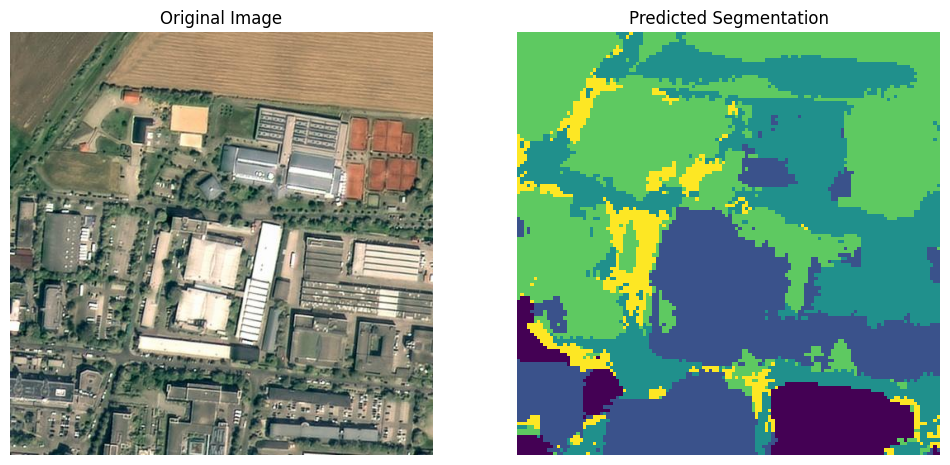

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask)
plt.title("Predicted Segmentation")
plt.axis("off")
plt.show()


In [ ]:
label_mask = np.vectorize(id2label.get)(predicted_mask)


In [ ]:
# Initialize blank RGB mask
rgb_mask = np.zeros((*predicted_mask.shape, 3), dtype=np.uint8)

# Paint each class with its color
for class_id, color in color_map.items():
    rgb_mask[predicted_mask == class_id] = color


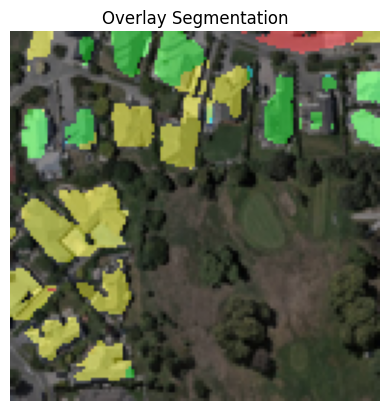

In [ ]:
# Convert image to numpy
image_np = np.array(image.resize(rgb_mask.shape[:2][::-1]))

# Blend original image with the mask
overlay = (0.6 * image_np + 0.4 * rgb_mask).astype(np.uint8)

plt.imshow(overlay)
plt.title("Overlay Segmentation")
plt.axis("off")
plt.show()


In [ ]:
id2label = model.config.id2label


In [ ]:
import numpy as np

# Apply id2label to each pixel
label_mask = np.vectorize(id2label.get)(predicted_mask)


In [ ]:
id2label = {
    0: "background",
    1: "residential",
    2: "commercial",
    3: "industrial",
    4: "public",
    5: "other"
}

color_map = {
    0: [0, 0, 0],         # background - black
    1: [255, 0, 0],       # residential - red
    2: [0, 255, 0],       # commercial - green
    3: [0, 0, 255],       # industrial - blue
    4: [255, 255, 0],     # road - yellow
    5: [0, 255, 255],     # tree - cyan
}


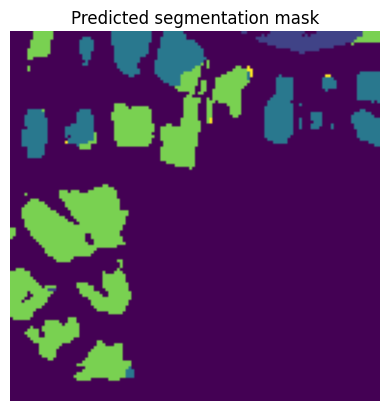

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(predicted_mask)
plt.title("Predicted segmentation mask")
plt.axis("off")
plt.show()


In [ ]:
trainer.push_to_hub()

model.safetensors:   0%|          | 0.00/256M [00:00<?, ?B/s]

Upload 3 LFS files:   0%|          | 0/3 [00:00<?, ?it/s]

events.out.tfevents.1751051352.531afbf886d3.1206.0:   0%|          | 0.00/749k [00:00<?, ?B/s]

training_args.bin:   0%|          | 0.00/5.30k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/tferhan/segformer-b4-finetuned-UBC/commit/be3c4c603d47f7d2adad78009015a7b794df86a8', commit_message='End of training', commit_description='', oid='be3c4c603d47f7d2adad78009015a7b794df86a8', pr_url=None, repo_url=RepoUrl('https://huggingface.co/tferhan/segformer-b4-finetuned-UBC', endpoint='https://huggingface.co', repo_type='model', repo_id='tferhan/segformer-b4-finetuned-UBC'), pr_revision=None, pr_num=None)